In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("Walmart.csv")
df.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,$74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,$15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,$46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,$58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,$86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10051 entries, 0 to 10050
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_id      10051 non-null  int64  
 1   Branch          10051 non-null  object 
 2   City            10051 non-null  object 
 3   category        10051 non-null  object 
 4   unit_price      10020 non-null  object 
 5   quantity        10020 non-null  float64
 6   date            10051 non-null  object 
 7   time            10051 non-null  object 
 8   payment_method  10051 non-null  object 
 9   rating          10051 non-null  float64
 10  profit_margin   10051 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 863.9+ KB


In [4]:
df.isnull().sum()

invoice_id         0
Branch             0
City               0
category           0
unit_price        31
quantity          31
date               0
time               0
payment_method     0
rating             0
profit_margin      0
dtype: int64

In [5]:
df.dropna(inplace=True)
df.isnull().sum()

invoice_id        0
Branch            0
City              0
category          0
unit_price        0
quantity          0
date              0
time              0
payment_method    0
rating            0
profit_margin     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(51)

In [7]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [8]:
df["date"]=pd.to_datetime(df["date"],format="mixed",errors="coerce")
df["hour"]=pd.to_datetime(df["time"],format="mixed",errors="coerce").dt.hour

In [9]:
df["Year"]=pd.DatetimeIndex(df["date"]).year
df["Day_shifts"]=pd.cut(x=df["hour"],bins=[-1,11,16,24],labels=["Morning","Afternoon","Evening"])

In [10]:
df["Day"]=pd.DatetimeIndex(df["date"]).weekday
label={0:"Monday",1:"Tuesday",2:"Wednesday",3:"Thursday",4:"Friday",5:"Saturday",6:"Sunday"}
df["Day"]=df["Day"].map(label)

In [11]:
df["unit_price"]=df["unit_price"].str.replace("$","").astype(float)

In [12]:
df["Sales"] =df["unit_price"]*df["quantity"]
df["profit"] =df["unit_price"]*df["quantity"]*df["profit_margin"]

In [13]:
pivot=df.pivot_table(index="Branch",columns="category",values="rating")
category=pivot.idxmax(axis=1)
ratings=pivot.max(axis=1)
toprated=pd.DataFrame({"Category":category,"Rating":ratings}).reset_index()
toprated.head()

,Branch,Category,Rating
0,WALM001,Electronic accessories,7.450000
1,WALM002,Food and beverages,8.250000
2,WALM003,Sports and travel,7.500000
3,WALM004,Food and beverages,9.300000
4,WALM005,Health and beauty,8.366667


# Average Category Rating

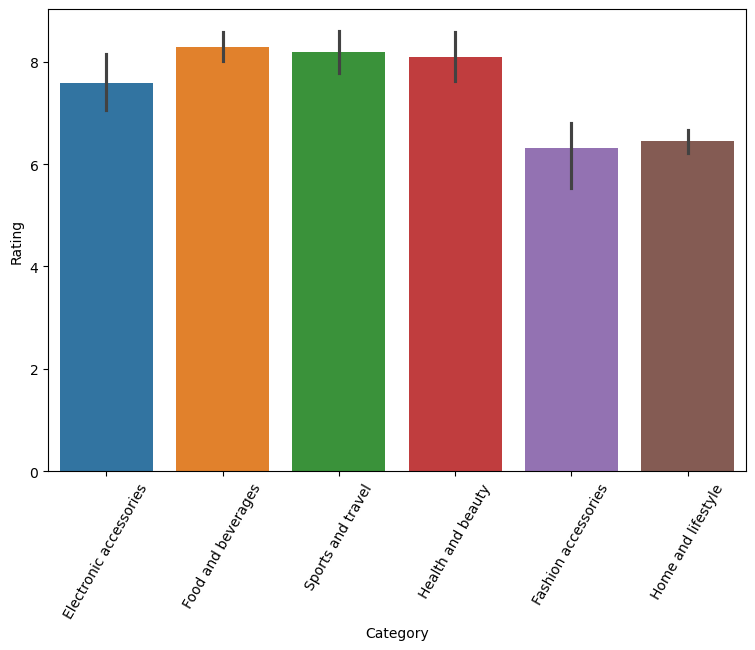

In [14]:
plt.figure(figsize=(9,6))
sns.barplot(data=toprated,x="Category",y="Rating",hue="Category")
plt.xticks(rotation=60)
plt.show()

### Conclusion
**"Food and Beverage" has highest average rating followed by "sports and travel". meanwhile "Fashion accessories" and "home and lifestyle" hold lowest rating ,Therefore these categories should be improved**

# Most Used Payment Method

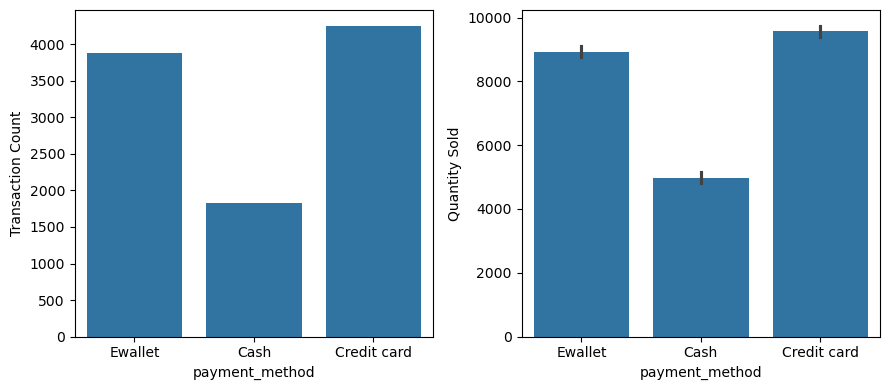

In [15]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
sns.countplot(x=df["payment_method"])
plt.ylabel("Transaction Count")

plt.subplot(1,2,2)
sns.barplot(x=df["payment_method"],y=df["quantity"],estimator="sum")
plt.ylabel("Quantity Sold")
plt.tight_layout()
plt.show()

### Conclusion
**Credit card is the most used payment method followed by Ewallet.**

# Transaction count based on Day of the Week

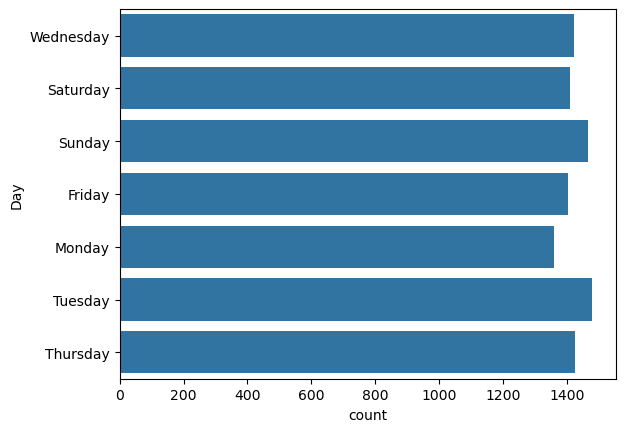

In [16]:
sns.countplot(df["Day"])
plt.show()

### Conclusion
**Tuesday has the highest number of transaction followed by sunday**

# Transaction count based on Time of the Day

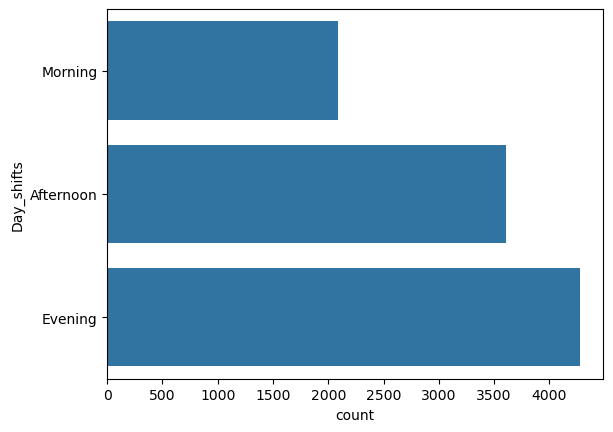

In [17]:
sns.countplot(df["Day_shifts"])
plt.show()

### Conclusion
**Evening has the highest number of transaction followed by Afternoon, morning has comparatively low transaction count**

# Sales vs Profit over year

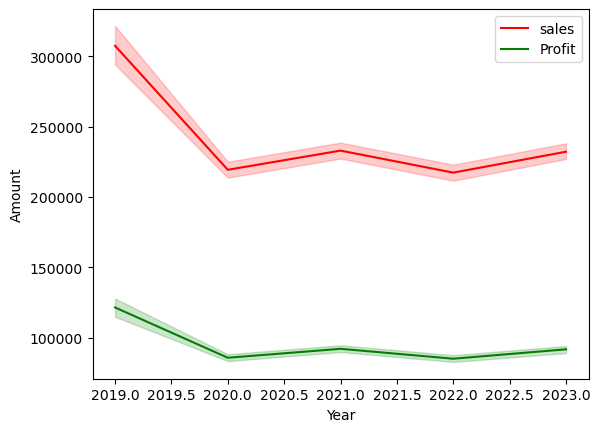

In [18]:
sns.lineplot(data=df,y="Sales",x="Year",label="sales",color="red",estimator="sum")
sns.lineplot(data=df,y="profit",x="Year",label="Profit",color="green",estimator="sum")
plt.ylabel("Amount")
plt.show()

### Conclusion
**Sales fell steeply in 2020 compared to 2019 and never recovered back to sales volume of year 2019 level across 2021-2023. profit followed parallel trend throughout the same period**

# Category wise Sales and Profit

[]

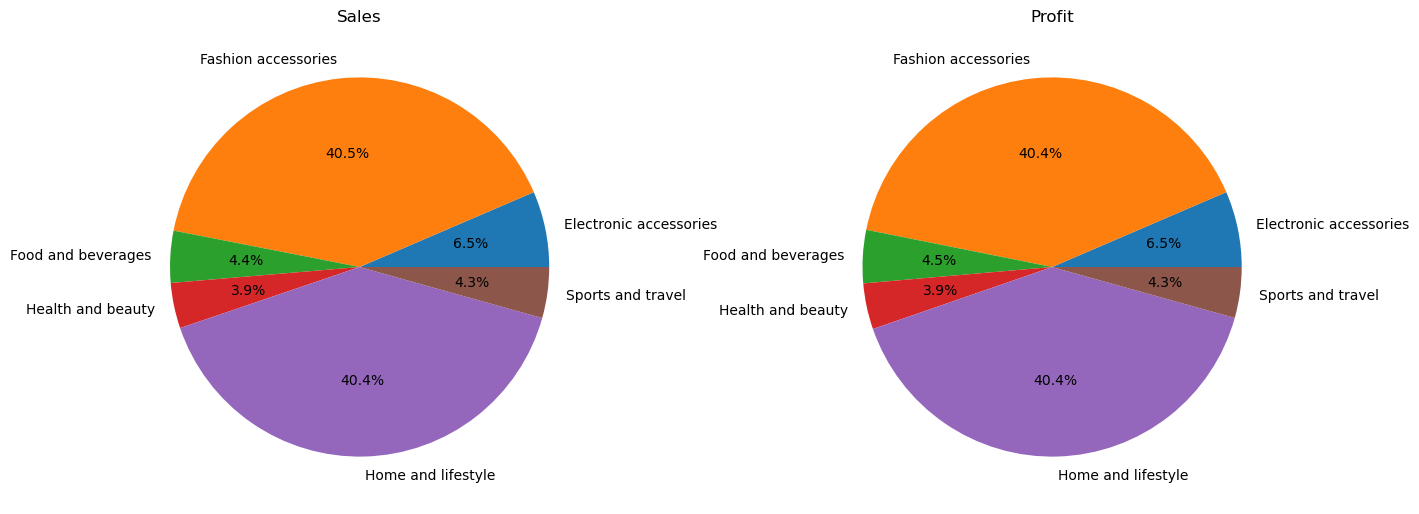

In [19]:
categorysales=df.groupby(by="category")["Sales"].sum().reset_index()
categoryprofit=df.groupby(by="category")["profit"].sum().reset_index()

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title("Sales")
plt.pie(categorysales["Sales"], labels=categorysales["category"],autopct="%1.1f%%")

plt.subplot(1,2,2)
plt.title("Profit")
plt.pie(categoryprofit["profit"], labels=categoryprofit["category"],autopct="%1.1f%%")

plt.tight_layout()
plt.plot()

### Conclusion
**"Fashion accessories" and "Home and lifestyle" categories makes most of the sales and profit**

# Exporting Processed Data to Excel

In [20]:
df.to_excel("Walmart_formated_data.xlsx",index=False)